Test cases:

0. No DM- ions should stay at equilibrium position
1. DM moves very very slowly- The force applied to the ions is quasi-static (compared to trap frequencies). We expect to see no excitation but shifting equilibrium position. 
2. DM moves very very quickly. Force is like a delta function. As force approaches delta function, the smaller the kick is. We expect the interaction to resemble the Rutherford scattering. 
3. DM moves at a speed such that interaction time with ions ~1/omega. The ions should have maximum amplitude.  

In [ ]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z_offset = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e

eps = 1
alpha = 1/137.06
d_chain = 3.7066438742e-06  # 3.7 µm separation between ions
delta_ion_2 = 0#-4.9903032463e-14 # small displacement of ion 2
m_dm = 1e-27
m_ion = c.m 
Z_charge = c.Z
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega = 2*pi*np.array([freq_x,freq_y,freq_z])
hbar = 1.0545718e-34 
mode_y = 2*pi*np.array([3031200.01,2944587.06,2818861.50])
mode_z = 2*pi*np.array([3002153.56,2914677.59,2787603.39])

In [22]:
# RF pseudo-force
def FRF(x,y,z,m=c.m,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    # --- FORCE EVERYTHING TO SCALARS ---
    x = float(x)
    y = float(y)
    z = float(z)
    m = float(np.asarray(m).ravel()[0])
    q = float(np.asarray(q).ravel()[0])
    omrf = float(np.asarray(omrf).ravel()[0])
    VRF = float(np.asarray(VRF).ravel()[0])
    Zc = float(np.asarray(Z_charge).ravel()[0])
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z) 
    divyparty=-2*divypart*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y)) 
    divypartz=2*divypart*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y)) 
    divzparty=-2*divzpart*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    divzpartz=2*divzpart*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z)) 
    return -1*((VRF*Z_charge*q)/(2*pi*np.sqrt(m)*omrf))**2*np.array([divypartz*0,divzparty+divyparty,divzpartz+divypartz])

# DC force
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def anatangrad(xi,yi,x,y,z,v): # gradient term of DC potential
    dy=y-yi
    dx=x-xi
    r = np.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return (v/(2*np.pi))*np.array([divx,divy,divz])

def FDC_single(x1,y1,x2,y2,x,y,z,v):
    return -Z_charge*e * (anatangrad(x2,y2,x,y,z,v)-anatangrad(x2,y1,x,y,z,v)-anatangrad(x1,y2,x,y,z,v)+anatangrad(x1,y1,x,y,z,v))

def FDC(x, y, z, m=c.m, q=c.e, omrf=c.omega,
        ymin=c.y11, yedge1=c.y21, yedge2=c.y12, ymax=c.y22):
    z_original = z
    force = np.zeros(3, dtype=float)
    # local copies forced to scalars (if these could be arrays)
    x = float(x); y = float(y); z_original = float(z_original)
    for k in range(0, 40):
        if (k != 19 and k != 39):
            z = z_original - z_offset  # keep scalar math
        else:
            z = z_original
        (x1k, y1k) = xy1k[k]
        (x2k, y2k) = xy2k[k]
        # enforce scalar on vk[k]
        v_k = float(np.asarray(vk[k]).ravel()[0])
        force_single = FDC_single(x1k, y1k, x2k, y2k, x, y, z, v_k)
        # ensure force_single is shape (3,)
        force_single = np.asarray(force_single, dtype=float).ravel()
        if force_single.shape != (3,):
            raise ValueError(f"FDC_single returned unexpected shape {force_single.shape} at k={k}")
        force += force_single
        # restore z (already set above each iteration; explicit restore optional)
        z = z_original
    return force

# Full Simulation Code

In [23]:
### Combined simulation code (from combined_full_simulation.ipynb)
def run_simulation(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, rtol=1e-13, atol=1e-16):
    """
    Run the coupled ion-chain / dark-matter trajectory simulation.

    Parameters
    ----------
    x0_dm : array-like, shape (3,)
        Initial position of the dark matter particle.
    v0_dm : array-like, shape (3,)
        Initial velocity of the dark matter particle.
    x0_ions : array-like, shape (3, 3)
        Initial positions of the 3 ions (rows = ions, columns = x,y,z).
        Used to build the initial state vector U0.
    v0_ions : array-like, shape (3, 3)
        Initial velocities of the 3 ions.
    t_span : tuple (t_start, t_end)
        Start and end time of the integration.
    dt : float
        Time increment used to build the evaluation grid
        (t_eval = arange(t_start, t_end, dt)).

    Returns
    -------
    t_eval : ndarray
        Times at which the solution was evaluated.
    x_dm_sol : ndarray, shape (3, N)
        DM position trajectory.
    v_dm_sol : ndarray, shape (3, N)
        DM velocity trajectory.
    x_ions_sol : ndarray, shape (9, N)
        Ion position trajectories (flattened, 3 ions x 3 coords).
    """

    x0_dm   = np.asarray(x0_dm, dtype=float)
    v0_dm   = np.asarray(v0_dm, dtype=float)
    x0_ions = np.asarray(x0_ions, dtype=float)
    v0_ions = np.asarray(v0_ions, dtype=float)

    # Trap restoring force pulls every ion toward the origin (the trap's
    # null point). Equilibrium chain spacing emerges from the balance
    # between this confinement and ion-ion Coulomb repulsion -- it is
    # NOT imposed here.
    r_ions_eq = np.zeros((3, 3), dtype=float)

    def rhs_unified(t, U, r_ions_eq, use_harmonic_ions=True):
        n_ions = 3

        x_ions = U[0:3*n_ions].reshape((n_ions, 3))
        x_dm   = U[3*n_ions:3*n_ions+3]
        v_ions = U[3*n_ions+3:3*n_ions+3+3*n_ions].reshape((n_ions, 3))
        v_dm   = U[-3:]

        dx_ionsdt = v_ions
        dx_dmdt   = v_dm

        dv_ionsdt = np.zeros_like(x_ions)
        dv_dmdt   = np.zeros(3)

        # --- Trap field (DM always uses full field) ---
        dc_dm = np.asarray(FDC(*x_dm))
        rf_dm = np.asarray(FRF(*x_dm))
        E_dm  = (dc_dm + rf_dm) / e
        dv_dmdt += (eps * e / m_dm) * E_dm

        # --- Ion dynamics ---
        for i in range(n_ions):

            if use_harmonic_ions:
                # Linearized trap around the origin (trap's true center)
                dv_ionsdt[i] += -omega**2 * (x_ions[i] - r_ions_eq[i])
            else:
                # Full trap field (same as DM but charge Z*e)
                dc_i = np.asarray(FDC(*x_ions[i]))
                rf_i = np.asarray(FRF(*x_ions[i]))
                E_i  = (dc_i + rf_i) / e
                dv_ionsdt[i] += (Z * e / m_ion) * E_i

            # --- Coulomb: ion <-> DM ---
            delta = x_ions[i] - x_dm
            r = np.linalg.norm(delta)

            force = K * eps * e**2 * delta / r**3

            dv_ionsdt[i] += force / m_ion
            dv_dmdt      -= force / m_dm   # enforce symmetry

            # --- Coulomb: ion <-> ion ---
            for j in range(i+1, n_ions):
                delta_ij = x_ions[i] - x_ions[j]
                r_ij = np.linalg.norm(delta_ij)

                fij = K * e**2 * delta_ij / r_ij**3

                dv_ionsdt[i] += fij / m_ion
                dv_ionsdt[j] -= fij / m_ion

        return np.concatenate([
            dx_ionsdt.flatten(), dx_dmdt,
            dv_ionsdt.flatten(), dv_dmdt
        ])

    print("Initial DM position:", x0_dm)
    print("Initial DM velocity:", v0_dm)

    # Flatten initial state
    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # Build time grid from t_span and dt
    t_eval = np.arange(t_span[0], t_span[1], dt)

    # Solve
    sol = solve_ivp(rhs_unified, t_span, U0, method='DOP853',
                     t_eval=t_eval, dense_output=True,
                     rtol=rtol, atol=atol, args=(r_ions_eq,))

    print("Success?", sol.success)
    print("Message:", sol.message)
    print("Final time:", sol.t[-1])

    # Extract solutions
    n_ions = 3
    x_ions_sol = sol.y[0:3*n_ions]
    x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]   # (3, N)
    v_ions_sol = sol.y[3*n_ions+3:3*n_ions+3*n_ions+3]
    v_dm_sol   = sol.y[-3:]

    return t_eval, x_dm_sol, v_dm_sol, x_ions_sol, v_ions_sol

def run_simulation_rutherford(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, rtol=1e-13, atol=1e-16):
    """
    Run the coupled ion-chain / dark-matter trajectory simulation with one ion without trap potential.
    """

    x0_dm   = np.asarray(x0_dm, dtype=float)
    v0_dm   = np.asarray(v0_dm, dtype=float)
    x0_ions = np.asarray(x0_ions, dtype=float)
    v0_ions = np.asarray(v0_ions, dtype=float)

    # Trap restoring force pulls every ion toward the origin (the trap's
    # null point). Equilibrium chain spacing emerges from the balance
    # between this confinement and ion-ion Coulomb repulsion -- it is
    # NOT imposed here.
    r_ions_eq = np.zeros((1,3), dtype=float) # np.zeros((3, 3), dtype=float)

    def rhs_unified(t, U, r_ions_eq, use_harmonic_ions=True):
        n_ions = 1 #3

        x_ions = U[0:3*n_ions].reshape((n_ions, 3))
        x_dm   = U[3*n_ions:3*n_ions+3]
        v_ions = U[3*n_ions+3:3*n_ions+3+3*n_ions].reshape((n_ions, 3))
        v_dm   = U[-3:]

        dx_ionsdt = v_ions
        dx_dmdt   = v_dm

        dv_ionsdt = np.zeros_like(x_ions)
        dv_dmdt   = np.zeros(3)

        # --- Trap field (DM always uses full field) ---
        dc_dm = 0 #np.asarray(FDC(*x_dm))
        rf_dm = 0 #np.asarray(FRF(*x_dm))
        E_dm  = (dc_dm + rf_dm) / e
        dv_dmdt += (eps * e / m_dm) * E_dm

        # --- Ion dynamics ---
        for i in range(n_ions):

            if use_harmonic_ions:
                # Linearized trap around the origin (trap's true center)
                dv_ionsdt[i] += 0 #-omega**2 * (x_ions[i] - r_ions_eq[i])
            else:
                # Full trap field (same as DM but charge Z*e)
                dc_i = np.asarray(FDC(*x_ions[i]))
                rf_i = np.asarray(FRF(*x_ions[i]))
                E_i  = (dc_i + rf_i) / e
                dv_ionsdt[i] += (Z * e / m_ion) * E_i

            # --- Coulomb: ion <-> DM ---
            delta = x_ions[i] - x_dm
            r = np.linalg.norm(delta)

            force = K * eps * e**2 * delta / r**3

            dv_ionsdt[i] += force / m_ion
            dv_dmdt      -= force / m_dm   # enforce symmetry

            # --- Coulomb: ion <-> ion ---
            for j in range(i+1, n_ions):
                delta_ij = x_ions[i] - x_ions[j]
                r_ij = np.linalg.norm(delta_ij)

                fij = K * e**2 * delta_ij / r_ij**3

                dv_ionsdt[i] += fij / m_ion
                dv_ionsdt[j] -= fij / m_ion

        return np.concatenate([
            dx_ionsdt.flatten(), dx_dmdt,
            dv_ionsdt.flatten(), dv_dmdt
        ])

    print("Initial DM position:", x0_dm)
    print("Initial DM velocity:", v0_dm)

    # Flatten initial state
    U0 = np.concatenate([x0_ions.flatten(), x0_dm, v0_ions.flatten(), v0_dm]).astype(float)

    # Build time grid from t_span and dt
    t_eval = np.arange(t_span[0], t_span[1], dt)

    # Solve
    sol = solve_ivp(rhs_unified, t_span, U0, method='DOP853',
                     t_eval=t_eval, dense_output=True,
                     rtol=rtol, atol=atol, args=(r_ions_eq,))

    print("Success?", sol.success)
    print("Message:", sol.message)
    print("Final time:", sol.t[-1])

    # Extract solutions
    n_ions = 1 #3
    x_ions_sol = sol.y[0:3*n_ions]
    x_dm_sol   = sol.y[3*n_ions:3*n_ions+3]   # (3, N)
    v_ions_sol = sol.y[3*n_ions+3:3*n_ions+3*n_ions+3]
    v_dm_sol   = sol.y[-3:]

    return t_eval, x_dm_sol, v_dm_sol, x_ions_sol, v_ions_sol

In [24]:
def curve_fit_ion_motion(t, t_min, dt, r_ion,mode):
    index = (int)(t_min/dt)
    t = t[index:]
    r_ion = r_ion[index:]
    def ion_motion_model(t, A, B, C):
        return A * np.cos(mode[0]*t) + B * np.cos(mode[1]*t) + C * np.cos(mode[2]*t)
    popt, pcov = curve_fit(ion_motion_model, t, r_ion, p0=[np.max(r_ion), 0,0])
    residuals = r_ion - ion_motion_model(t, *popt)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((r_ion - np.mean(r_ion))**2)
    # Calculate R^2
    r_squared = 1 - (ss_res / ss_tot)
    print(f"Fitted parameters: A={popt[0]}, B={popt[1]}, C={popt[2]}")
    print(f"Fitted model: r_ion(t) = {popt[0]:.3e} * cos({mode[0]:.3e} * t) + {popt[1]:.3e} * cos({mode[1]:.3e} * t) + {popt[2]:.3e} * cos({mode[2]:.3e} * t)")
    print(f"R² Score: {r_squared}")
    return popt[0], popt[1], popt[2]

In [25]:
def analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, t_min, fit_curve, rutherford, show_plots,
                                rtol=1e-13, atol=1e-16):
    if(rutherford):
        t00, xdm00, vdm00, xion00, vion00 = run_simulation_rutherford(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, rtol=rtol, atol=atol)
    else:
        t00, xdm00, vdm00, xion00, vion00 = run_simulation(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, rtol=rtol, atol=atol)
    t0 = t00/um
    xdm0 = xdm00/um
    vdm0 = vdm00
    xion0 = xion00/um
    vion0 = vion00
    x0, y0, z0 = xdm0
    x0_ion1, y0_ion1, z0_ion1 = xion0[0], xion0[1], xion0[2] # motion of left ion
    if(not rutherford):
        x0_ion2, y0_ion2, z0_ion2 = xion0[3], xion0[4], xion0[5] # motion of center ion
        x0_ion3, y0_ion3, z0_ion3 = xion0[6], xion0[7], xion0[8] # motion of right ion

    d = np.sqrt(x0**2 + y0**2 + z0**2) # for DM
    d_ion1 = np.sqrt((x0_ion1+d_chain)**2+y0_ion1**2+z0_ion1**2)
    if(not rutherford):
        d_ion2 = np.sqrt(x0_ion2**2+y0_ion2**2+z0_ion2**2)
        d_ion3 = np.sqrt((x0_ion3-d_chain)**2+y0_ion3**2+z0_ion3**2)
    print(f"Ending position of DM: {xdm0[:, -1]} um")
    print(f"Ending velocity of DM: {vdm0[:, -1]} um/us")

    ## Fit curve
    if(fit_curve):
        print("--------------------------")
        print("Fitting ion y-motion to model...")
        A1_y, B1_y, C1_y = curve_fit_ion_motion(t00, t_min-t_span[0], dt, y0_ion1, mode_y)
        A2_y, B2_y, C2_y = curve_fit_ion_motion(t00, t_min-t_span[0], dt, y0_ion2, mode_y)
        A3_y, B3_y, C3_y = curve_fit_ion_motion(t00, t_min-t_span[0], dt, y0_ion3, mode_y)
        print("--------------------------")
        print("Fitting ion z-motion to model...")
        A1_z, B1_z, C1_z = curve_fit_ion_motion(t00, t_min-t_span[0], dt, z0_ion1, mode_z)
        A2_z, B2_z, C2_z = curve_fit_ion_motion(t00, t_min-t_span[0], dt, z0_ion2, mode_z)
        A3_z, B3_z, C3_z = curve_fit_ion_motion(t00, t_min-t_span[0], dt, z0_ion3, mode_z)

    ## Plots of the DM trajectory
    if(show_plots):
        plt.figure(figsize=(18,5))

        # XY
        plt.subplot(1,3,1)
        plt.plot(x0, y0)
        plt.xlabel("x (um)")
        plt.ylabel("y (um)")
        plt.title("DM trajectory: XY plane")
        plt.legend()

        # XZ
        plt.subplot(1,3,2)
        plt.plot(x0, z0)
        plt.xlabel("x (um)")
        plt.ylabel("z (um)")
        plt.title("DM trajectory: XZ plane")
        plt.legend()

        # YZ
        plt.subplot(1,3,3)
        plt.plot(y0, z0)
        plt.xlabel("y (um)")
        plt.ylabel("z (um)")
        plt.title("DM trajectory: YZ plane")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # DM distance vs time
        plt.figure()
        plt.plot(t0, d)
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("DM distance from origin vs time")
        plt.legend()

        ## Plots for ion trajectory
        plt.figure(figsize=(18,5))

        # ion 1 XY-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion1, y0_ion1, label="ion 1")
        plt.xlabel("x (um)")
        plt.ylabel("y (um)")
        plt.title("Ion trajectory: XY plane")
        plt.legend()

        # ion 2 XY-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion2, y0_ion2, label="ion 2")
        plt.xlabel("x (um)")
        plt.ylabel("y (um)")
        plt.title("Ion trajectory: XY plane")
        plt.legend()

        # ion 3 XY-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion3, y0_ion3, label="ion 3")
        plt.xlabel("x (um)")
        plt.ylabel("y (um)")
        plt.title("Ion trajectory: XY plane")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # ion 1 XZ-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion1, z0_ion1, label="ion 1")
        plt.xlabel("x (um)")
        plt.ylabel("z (um)")
        plt.title("Ion trajectory: XZ plane")
        plt.legend()

        # ion 2 XZ-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion2, z0_ion2, label="ion 2")
        plt.xlabel("x (um)")
        plt.ylabel("z (um)")
        plt.title("Ion trajectory: XZ plane")
        plt.legend()

        # ion 3 XZ-trajectory
        plt.subplot(1,3,1)
        plt.plot(x0_ion3, z0_ion3, label="ion 3")
        plt.xlabel("x (um)")
        plt.ylabel("z (um)")
        plt.title("Ion trajectory: XZ plane")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # ion 1 distance vs time
        plt.figure(figsize=(18,5))
        plt.subplot(1,3,1)
        plt.plot(t0, d_ion1, label="ion 1")
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("ion distance from starting position vs time")
        plt.legend()

        # ion 2 distance vs time
        plt.subplot(1,3,1)
        plt.plot(t0, d_ion2, label="ion 2")
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("ion distance from starting position vs time")
        plt.legend()

        # ion 3 distance vs time
        plt.subplot(1,3,1)
        plt.plot(t0, d_ion3, label="ion 3")
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("ion distance from starting position vs time")
        plt.legend()

        # DM distance vs time
        plt.figure()
        plt.plot(t0, d)
        plt.xlabel("t (us)")
        plt.ylabel("distance (um)")
        plt.title("DM distance from origin vs time")
        plt.legend()

        plt.tight_layout()
        plt.show()

        # ion 1 x-position vs time
        plt.figure(figsize=(18,5))
        plt.subplot(1,3,1)
        plt.plot(t0, x0_ion1, label="ion 1")
        plt.xlabel("t (us)")
        plt.ylabel("x (um)")
        plt.title("Ion x-position vs time")
        plt.legend()

        # ion 2 x-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, x0_ion2, label="ion 2")
        plt.xlabel("t (us)")
        plt.ylabel("x (um)")
        plt.title("Ion x-position vs time")
        plt.legend()

        # ion 3 x-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, x0_ion3, label="ion 3")
        plt.xlabel("t (us)")
        plt.ylabel("x (um)")
        plt.title("Ion x-position vs time")
        plt.legend()

        # ion 1 y-position vs time
        plt.figure(figsize=(18,5))
        plt.subplot(1,3,1)
        plt.plot(t0, y0_ion1, label="ion 1")
        plt.xlabel("t (us)")
        plt.ylabel("y (um)")
        plt.title("Ion y-position vs time")
        plt.legend()

        # ion 2 y-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, y0_ion2, label="ion 2")
        plt.xlabel("t (us)")
        plt.ylabel("y (um)")
        plt.title("Ion y-position vs time")
        plt.legend()

        # ion 3 y-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, y0_ion3, label="ion 3")
        plt.xlabel("t (us)")
        plt.ylabel("y (um)")
        plt.title("Ion y-position vs time")
        plt.legend()

        # ion 1 z-position vs time
        plt.figure(figsize=(18,5))
        plt.subplot(1,3,1)
        plt.plot(t0, z0_ion1, label="ion 1")
        plt.xlabel("t (us)")
        plt.ylabel("z (um)")
        plt.title("Ion z-position vs time")
        plt.legend()

        # ion 2 z-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, z0_ion2, label="ion 2")
        plt.xlabel("t (us)")
        plt.ylabel("z (um)")
        plt.title("Ion z-position vs time")
        plt.legend()

        # ion 3 z-position vs time
        plt.subplot(1,3,1)
        plt.plot(t0, z0_ion3, label="ion 3")
        plt.xlabel("t (us)")
        plt.ylabel("z (um)")
        plt.title("Ion z-position vs time")
        plt.legend()

        plt.tight_layout()
        plt.show()

    return t00, xdm00, vdm00, xion00, vion00

Initial DM position: [ 2.11297150e-22 -2.32848015e-06 -3.13452024e-05]
Initial DM velocity: [-1.74379576e-13  1.80241199e+04  8.22121480e+04]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 0.0001009990000000022
Ending position of DM: [-3.17137596e-13  3.02042868e+03 -8.97803938e+04] um
Ending velocity of DM: [-3.16528498e-13  3.03346399e+03 -8.99728207e+04] um/us
--------------------------
Fitting ion y-motion to model...
Fitted parameters: A=0.00020994550993781591, B=0.0002477259361051059, C=0.00010662518995278378
Fitted model: r_ion(t) = 2.099e-04 * cos(1.905e+07 * t) + 2.477e-04 * cos(1.850e+07 * t) + 1.066e-04 * cos(1.771e+07 * t)
R² Score: 0.9970818677429398
Fitted parameters: A=0.0002498552409593614, B=9.112687766461551e-05, C=-0.00011297244748545382
Fitted model: r_ion(t) = 2.499e-04 * cos(1.905e+07 * t) + 9.113e-05 * cos(1.850e+07 * t) + -1.130e-04 * cos(1.771e+07 * t)
R² Score: 0.9744514767206607
Fitted parameters: A=0.0

C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


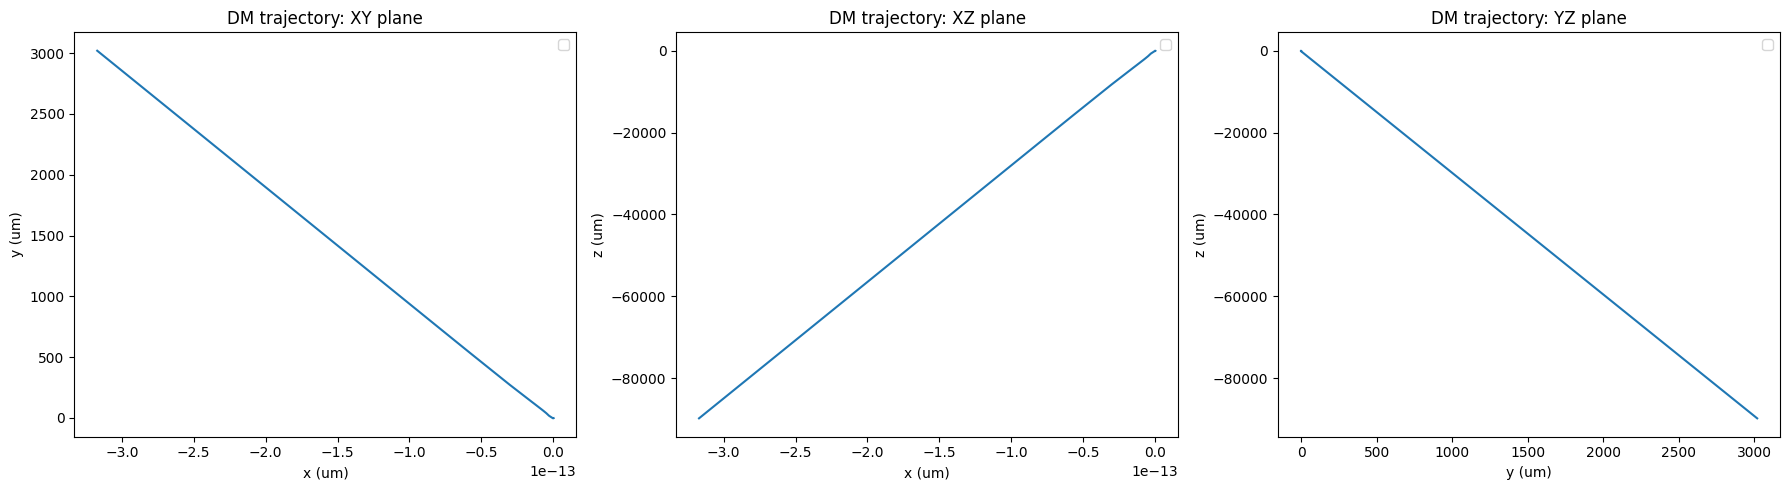

C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


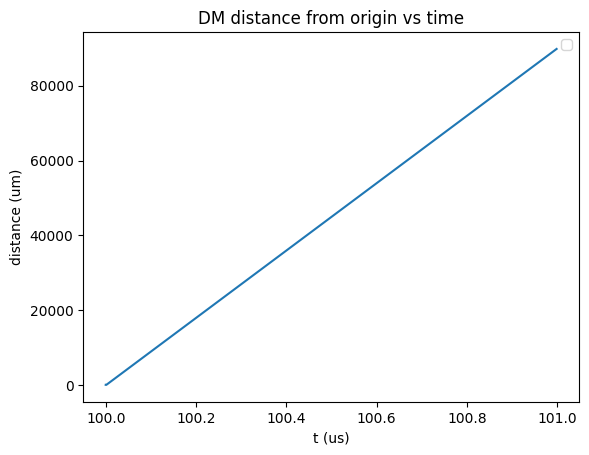

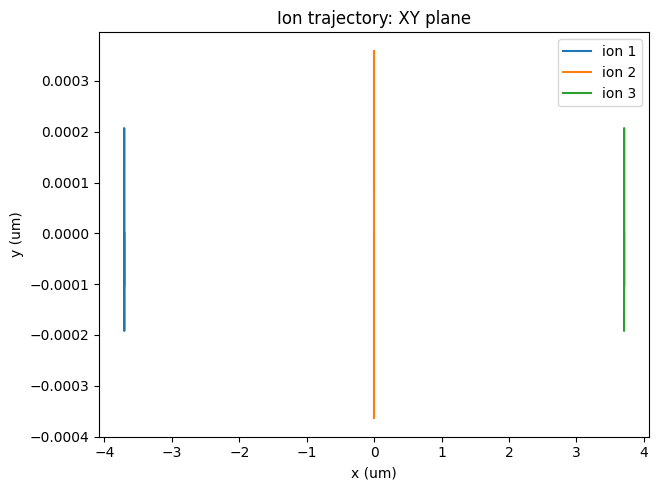

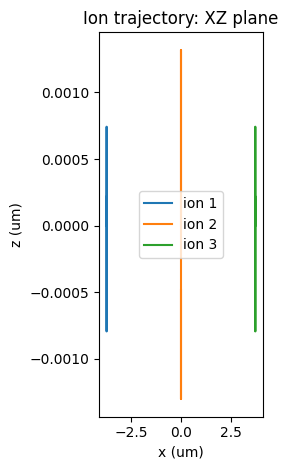

C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


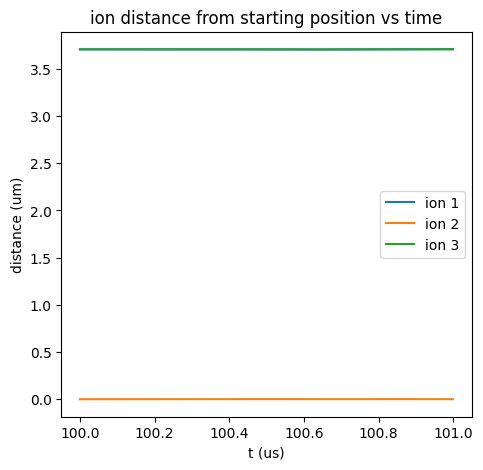

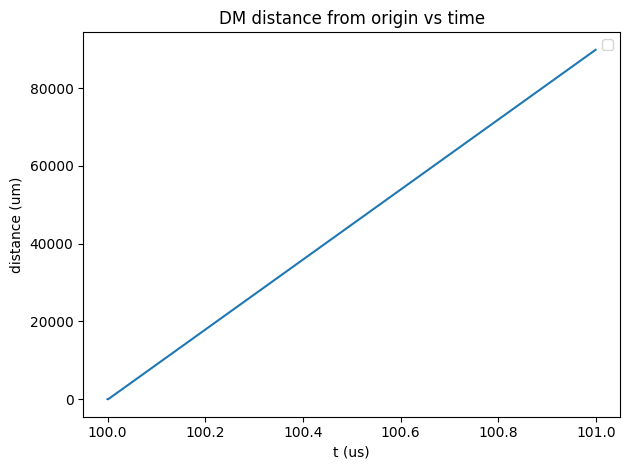

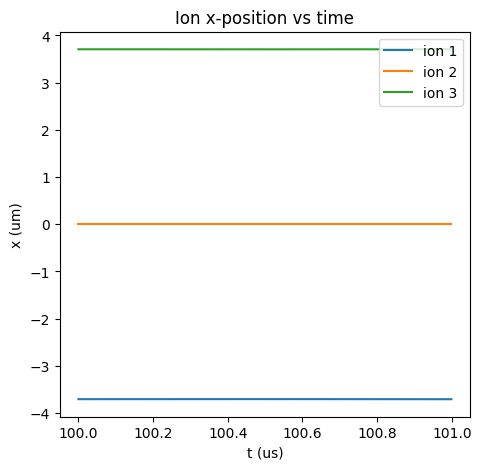

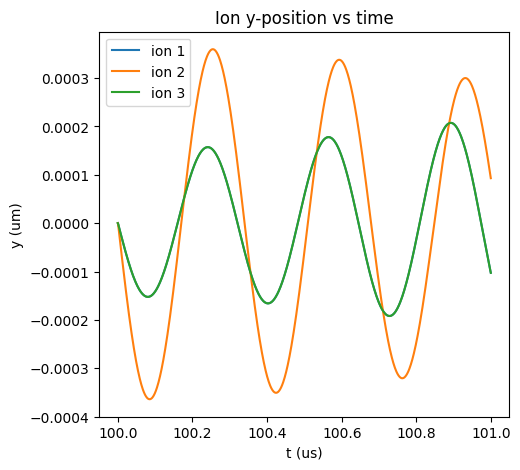

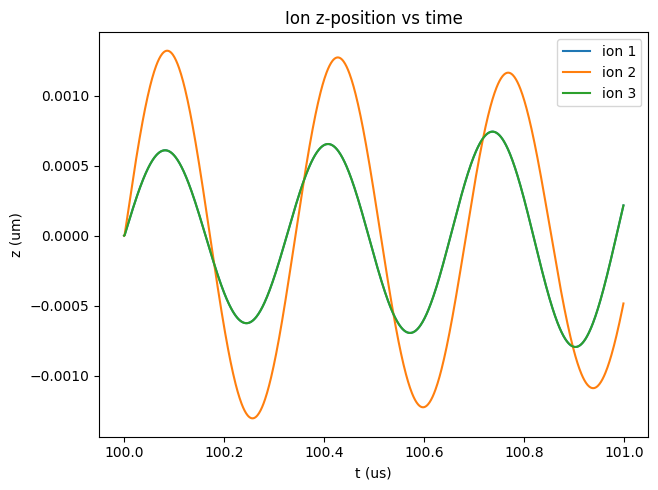

(array([0.0001    , 0.0001    , 0.0001    , 0.0001    , 0.0001    ,
        0.00010001, 0.00010001, 0.00010001, 0.00010001, 0.00010001,
        0.00010001, 0.00010001, 0.00010001, 0.00010001, 0.00010001,
        0.00010002, 0.00010002, 0.00010002, 0.00010002, 0.00010002,
        0.00010002, 0.00010002, 0.00010002, 0.00010002, 0.00010002,
        0.00010003, 0.00010003, 0.00010003, 0.00010003, 0.00010003,
        0.00010003, 0.00010003, 0.00010003, 0.00010003, 0.00010003,
        0.00010004, 0.00010004, 0.00010004, 0.00010004, 0.00010004,
        0.00010004, 0.00010004, 0.00010004, 0.00010004, 0.00010004,
        0.00010005, 0.00010005, 0.00010005, 0.00010005, 0.00010005,
        0.00010005, 0.00010005, 0.00010005, 0.00010005, 0.00010005,
        0.00010006, 0.00010006, 0.00010006, 0.00010006, 0.00010006,
        0.00010006, 0.00010006, 0.00010006, 0.00010006, 0.00010006,
        0.00010007, 0.00010007, 0.00010007, 0.00010007, 0.00010007,
        0.00010007, 0.00010007, 0.00010007, 0.00

In [26]:
# Run simulation
x0_ions = np.array([
    [-d_chain, 0, 0],
    [delta_ion_2, 0, 0],
    [d_chain, 0, 0]
], dtype=float)
v0_ions = np.zeros_like(x0_ions, dtype=float)

b = 0e-6  # impact parameter
x0_dm = np.array([2.1129714985500633e-22, -2.3284801494144364e-06, -3.134520244349659e-05], dtype=float)
v0_dm = np.array([-1.7437957579651323e-13, 18024.119934083286, 82212.14800628253], dtype=float)

t_span = (10e-5, 10.1e-5)
dt = 1e-9
t_min = 10e-5
analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, t_min, True, False, True)


# Test Case 1: DM -> Low Velocity

Back propagate DM and obtain difference in kinetic energy 
Initial DM position: [-1.e-06 -1.e-06  0.e+00]
Initial DM velocity: [0. 0. 0.]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.99e-08
Ending position of DM: [  -13.05661658   299.25076208 -8664.57775753] um
Ending velocity of DM: [  -121.49764174   3049.14256533 -88056.66916255] um/us
Difference in DM kinetic energy: 3.882e-18 J
---------------------------
Using the initial conditions from the main simulation, back propagate the DM
Initial DM position: [-1.30566166e-05  2.99250762e-04 -8.66457776e-03]
Initial DM velocity: [  121.49764174 -3049.14256533 88056.66916255]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.9999e-06
Ending position of DM: [  -1199.25737628   29960.69268271 -871638.84777062] um
Ending velocity of DM: [  -121.0442443    3026.87125342 -88057.67011863] um/us


C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


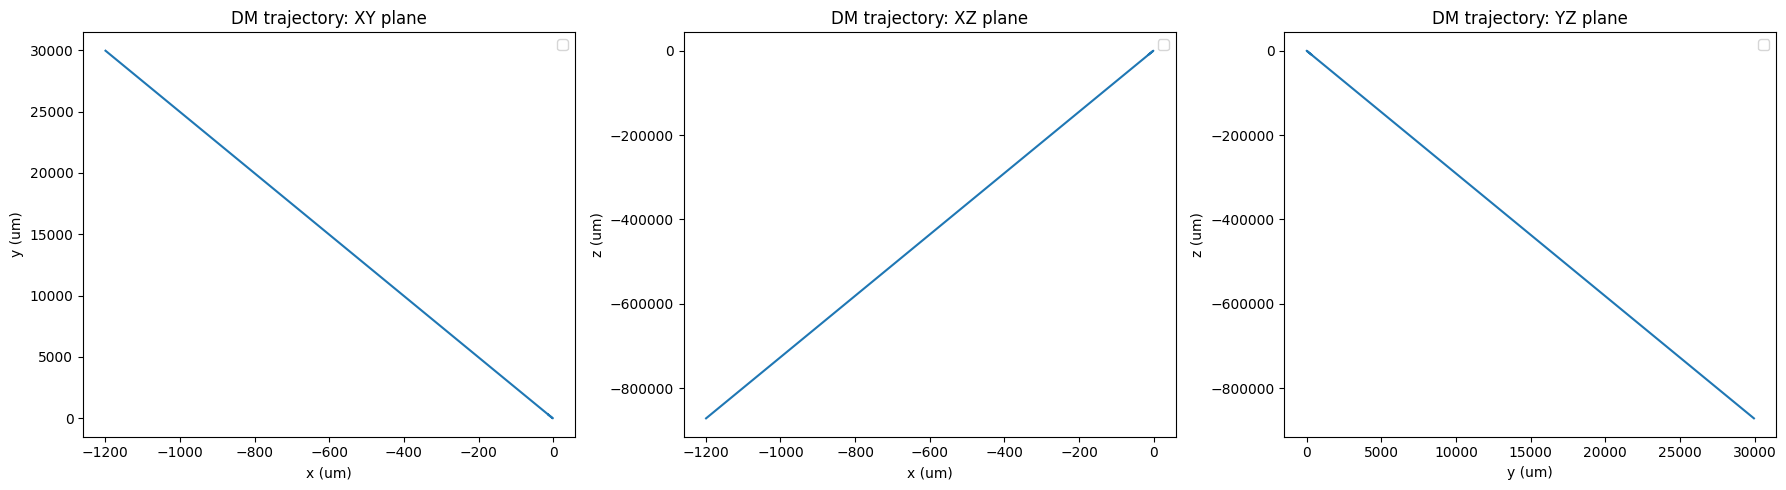

C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


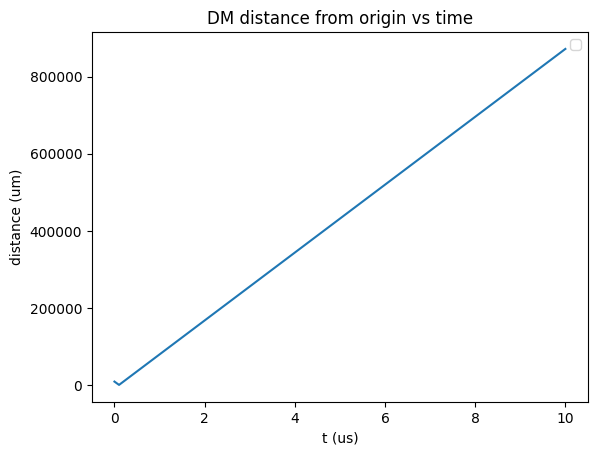

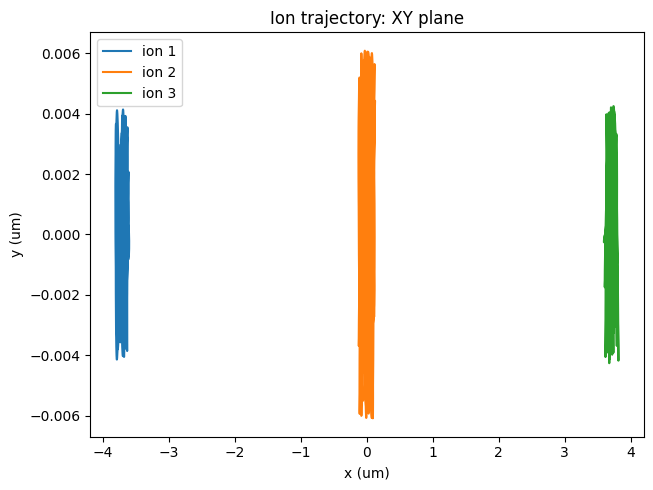

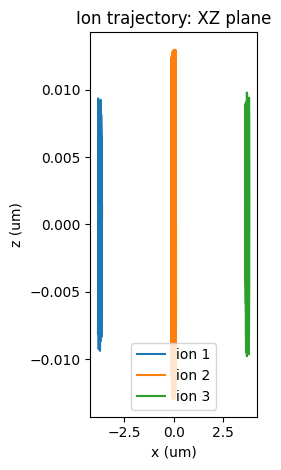

C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


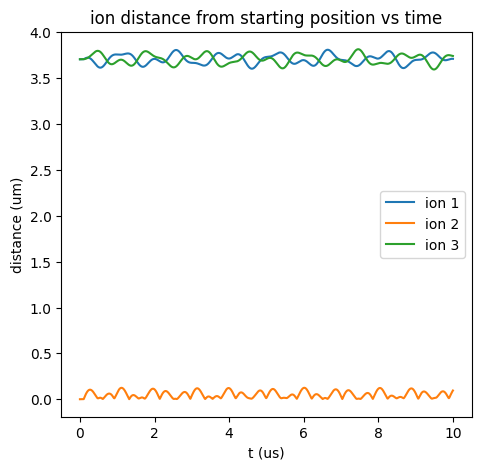

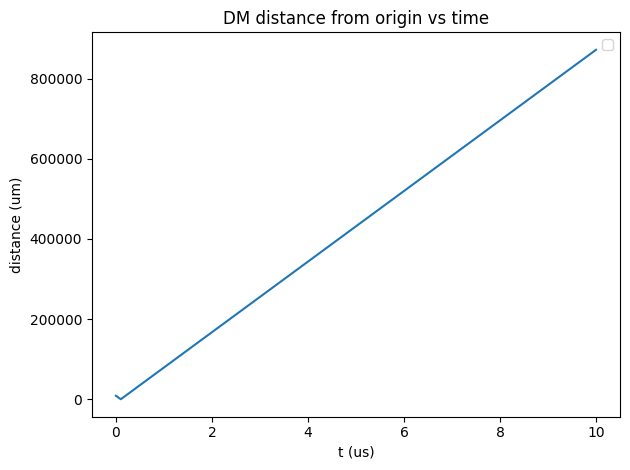

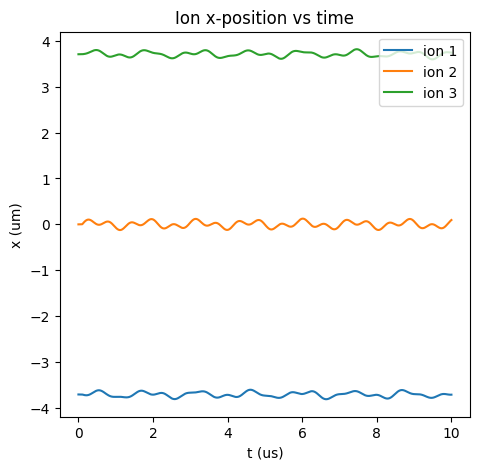

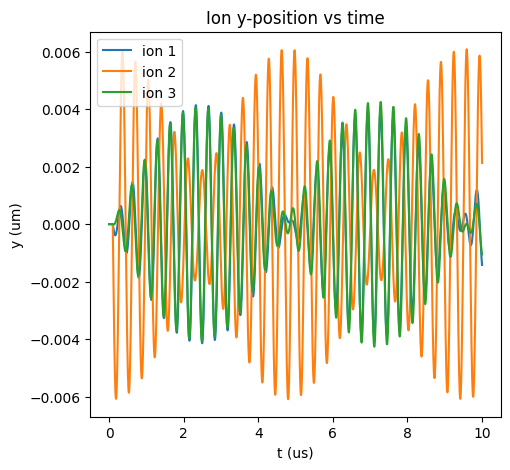

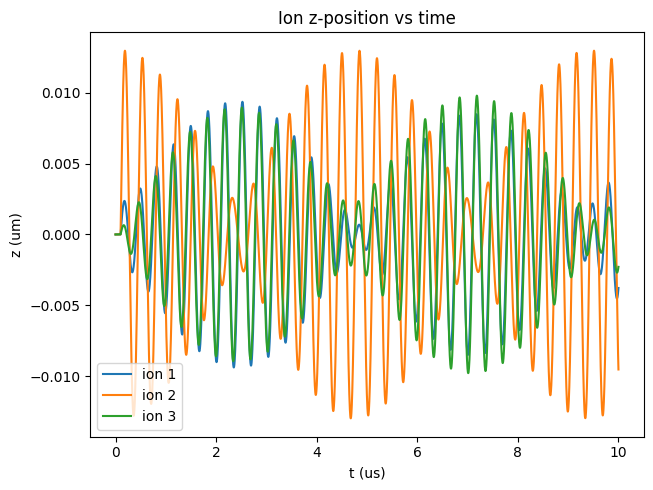

Position of DM at t=1.0e-07 s: [-9.99999111e-07 -9.99999224e-07 -1.15256952e-10] um
Velocity of DM at t=1.0e-07 s: [ 0.00693724  0.00222129 -0.53636029] um/us
Difference in DM kinetic energy: -3.882e-18 J
---------------------------
Steady state energy of ion 1: 8.541e-26 J
Steady state energy of ion 2: 1.434e-25 J
Steady state energy of ion 3: 7.198e-26 J
Total steady state energy of ions: 1.536e-25 J


In [27]:
### Test 1: DM moves very slowly
## Use eps = 0.1, m_dm = 1e-26 kg (modify first cell)
## Back propagate DM and obtain difference in kinetic energy 
print(f"Back propagate DM and obtain difference in kinetic energy ")
x0_ions = np.array([
    [-d_chain, 0, 0],
    [delta_ion_2, 0, 0],
    [d_chain, 0, 0]
], dtype=float)
v0_ions = np.zeros_like(x0_ions, dtype=float)
x0_dm = np.array([-1e-6, -1e-6, 0], dtype=float)   
v0_dm = np.array([0, 0, 0], dtype=float)   
t_span = (0, 1e-7)
dt = 1e-10
t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt,0,False,False,False)
E_diff = 0.5 * m_dm * np.linalg.norm(vdm0[:, -1])**2 - 0.5 * m_dm * np.linalg.norm(v0_dm)**2
print(f"Difference in DM kinetic energy: {E_diff:.3e} J")

## Using the initial conditions from the main simulation, back propagate the DM
print("---------------------------")
print(f"Using the initial conditions from the main simulation, back propagate the DM")
x0_dm = xdm0[:, -1]
v0_dm = -1*vdm0[:, -1]
index = (int)(t_span[1]/dt)
t_span = (0, 1e-5)  # New time scale
t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt,0,False,False,True)
# check that the difference in kinetic energy is the same (opposite sign) as before at the end of the old timespan
E_diff = 0.5 * m_dm * np.linalg.norm(vdm0[:, index])**2 - 0.5 * m_dm * np.linalg.norm(v0_dm)**2
print(f"Position of DM at t={dt*index:.1e} s: {xdm0[:, index]} um")
print(f"Velocity of DM at t={dt*index:.1e} s: {vdm0[:, index]} um/us")
print(f"Difference in DM kinetic energy: {E_diff:.3e} J")
# Steady state energy of ions
E_ion1 = 0.5 * m_ion * (vion0[0]**2 + vion0[1]**2 + vion0[2]**2)
E_ion2 = 0.5 * m_ion * (vion0[3]**2 + vion0[4]**2 + vion0[5]**2)
E_ion3 = 0.5 * m_ion * (vion0[6]**2 + vion0[7]**2 + vion0[8]**2)
E_total = E_ion1 + E_ion2 + E_ion3
print("---------------------------")
print(f"Steady state energy of ion 1: {max(E_ion1):.3e} J")
print(f"Steady state energy of ion 2: {max(E_ion2):.3e} J")
print(f"Steady state energy of ion 3: {max(E_ion3):.3e} J")
print(f"Total steady state energy of ions: {max(E_total):.3e} J")

# Test Case 2: Dark Matter-> high velocity

Initial DM position: [-0.001   0.0002  0.    ]
Initial DM velocity: [1.e+09 0.e+00 0.e+00]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.99e-07
Ending position of DM: [ 9.98999000e+08  3.88502067e+04 -2.05920461e+00] um
Ending velocity of DM: [ 1.00000000e+09  3.87157621e+04 -2.06198874e+00] um/us


C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


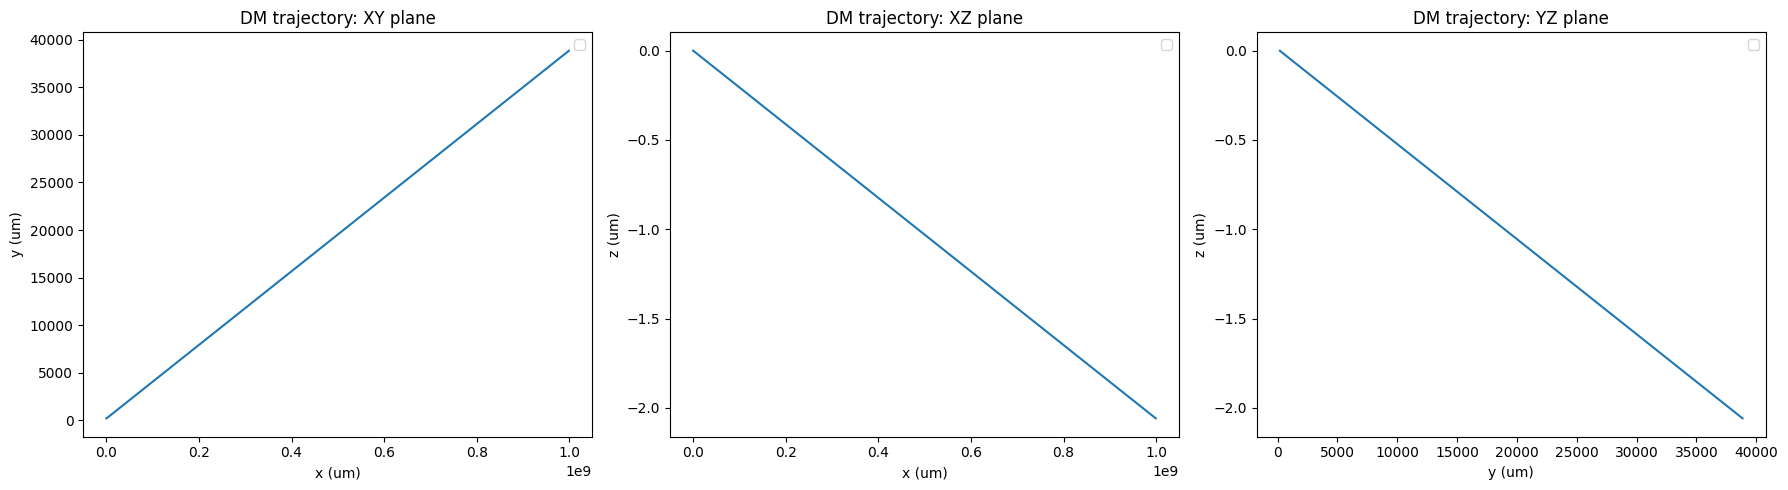

C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


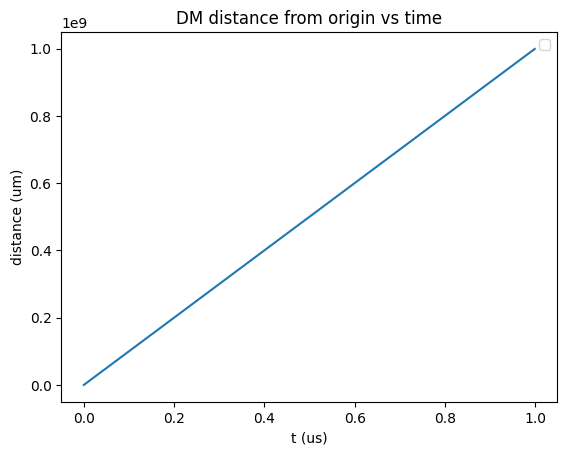

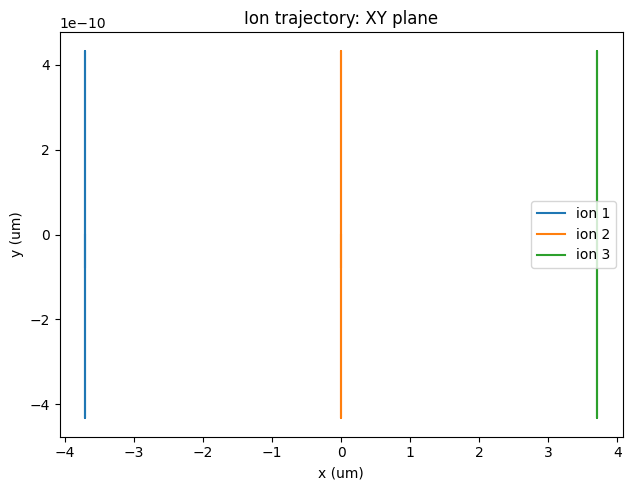

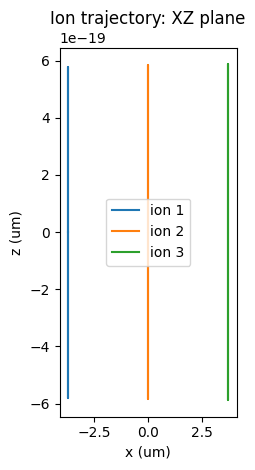

C:\Users\isach\AppData\Local\Temp\ipykernel_24404\2533879174.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


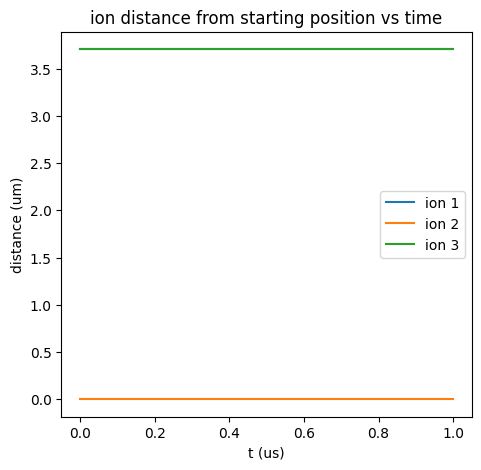

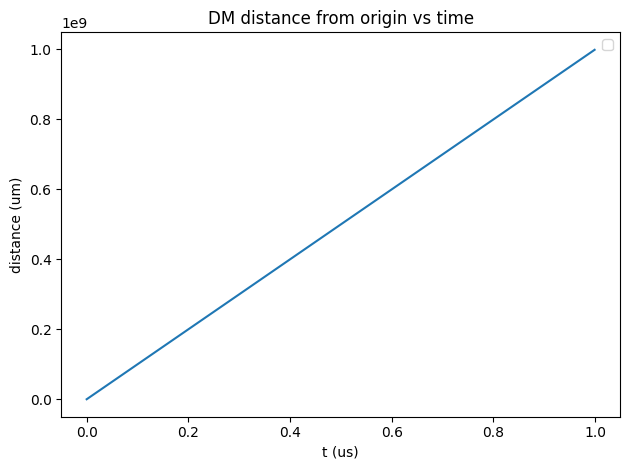

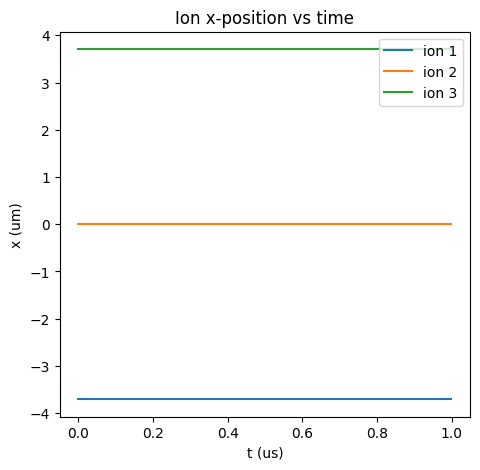

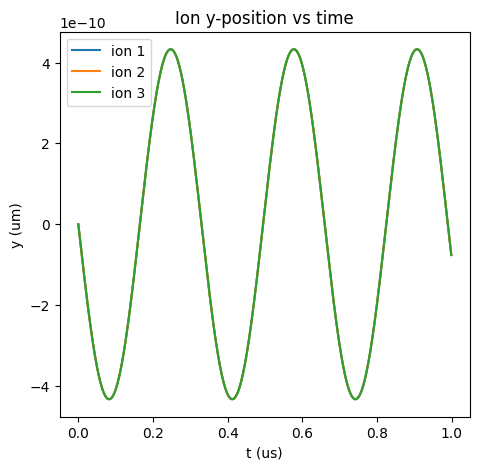

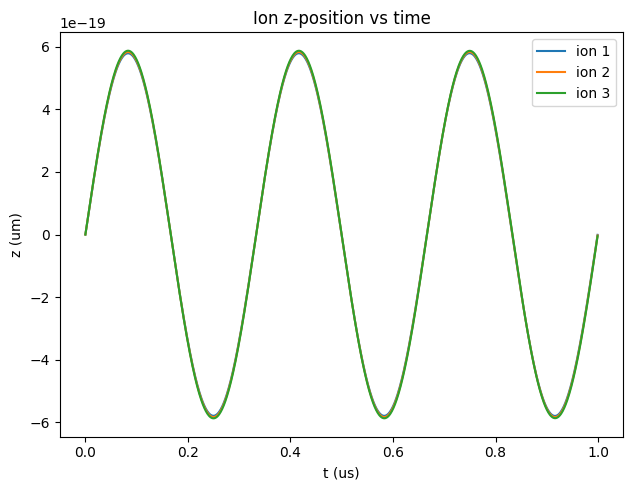

Observed energy of ion 1 after interaction: 7.269042952293813e-41 J
Observed energy of ion 2 after interaction: 9.741091029826768e-42 J
Observed energy of ion 3 after interaction: 7.235491362095452e-41 J
Observed total energy of ions after interaction: 1.522023748506157e-40 J
Initial DM position: [-0.001   0.0002  0.    ]
Initial DM velocity: [1.e+09 0.e+00 0.e+00]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 9.99e-07
Ending position of DM: [9.98999000e+08 2.00000002e+02 0.00000000e+00] um
Ending velocity of DM: [1.00000000e+09 2.34087385e-06 0.00000000e+00] um/us
Free-space total energy of ions after interaction: 9.743573481519824e-42 J


In [28]:
### Test 2: DM moves very quickly
## Run simulation/analyze results
x0_ions = np.array([
    [-d_chain, 0, 0],
    [delta_ion_2, 0, 0],
    [d_chain, 0, 0]
], dtype=float)
v0_ions = np.zeros_like(x0_ions, dtype=float)
b = 2e-4  # impact parameter
x0_dm = np.array([-1e-3,b,0], dtype=float)
v0_dm = np.array([1e9,0,0], dtype=float)
t_span         = (0.0, 1e-6)  
dt             = 1e-9 
t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt,0, False, False, True)

## Energy of ions after interaction
# Observed
E_ion1 = 0.5 * m_ion * (vion0[0]**2 + vion0[1]**2 + vion0[2]**2)
E_ion2 = 0.5 * m_ion * (vion0[3]**2 + vion0[4]**2 + vion0[5]**2)
E_ion3 = 0.5 * m_ion * (vion0[6]**2 + vion0[7]**2 + vion0[8]**2)
E_total = E_ion1 + E_ion2 + E_ion3
print(f"Observed energy of ion 1 after interaction: {max(E_ion1)} J")
print(f"Observed energy of ion 2 after interaction: {max(E_ion2)} J")
print(f"Observed energy of ion 3 after interaction: {max(E_ion3)} J")
print(f"Observed total energy of ions after interaction: {max(E_total)} J")
# Free space
x0_ions = np.array([delta_ion_2, 0, 0], dtype=float)
v0_ions = np.zeros_like(x0_ions, dtype=float)
t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt,0, False, True, False)
E_ion_fs = 0.5 * m_ion * (vion0[0]**2 + vion0[1]**2 + vion0[2]**2)
print(f"Free-space total energy of ions after interaction: {E_ion_fs[-1]} J")


# Test Case 3 : Maximum Amplitude at Resonant Condition

In [ ]:

import scipy.integrate
_original_solve_ivp = scipy.integrate.solve_ivp

def _loose_solve_ivp(*args, **kwargs):
    kwargs['rtol'] = 1e-9
    kwargs['atol'] = 1e-12
    return _original_solve_ivp(*args, **kwargs)

solve_ivp = _loose_solve_ivp   

omega_y = omega[1]
T = 2*pi/omega_y
b = 2e-4
xi_star = 1.25
v_res = omega_y * b / xi_star
print(f"Resonant velocity: {v_res:.3e} m/s")

velocities = {
    "below resonance": v_res / 3,   # xi ~ 3.75
    "resonant":        v_res,        # xi ~ 1.25
    "above resonance": v_res * 3,    # xi ~ 0.417
}

n_periods = 20
n_periods_impact = 10
dt = T / 50
t_span = (0.0, n_periods * T)

amplitudes = {}

try:
    for label, v in velocities.items():
        x0_ions = np.array([
            [-d_chain, 0, 0],
            [delta_ion_2, 0, 0],
            [d_chain, 0, 0]
        ], dtype=float)
        v0_ions = np.zeros_like(x0_ions, dtype=float)

        x0_dm = np.array([-v * n_periods_impact * T, b, 0], dtype=float)
        v0_dm = np.array([v, 0, 0], dtype=float)

        xi = omega_y * b / v
        t0, xdm0, vdm0, xion0, vion0 = analyze_simulation_results(
            x0_dm, v0_dm, x0_ions, v0_ions, t_span, dt, 0, False, False, False
        )
        y_ion2 = xion0[4]

        t_mid = n_periods_impact * T
        post_mask = t0 > (t_mid + 5 * T)
        peak_amp = np.max(np.abs(y_ion2[post_mask]))

        amplitudes[label] = peak_amp
        print(f"Peak residual |y| amplitude of ion 2 (post-encounter): {peak_amp:.3e} m\n")
finally:
    solve_ivp = _original_solve_ivp  

print("=== Summary ===")
for label, amp in amplitudes.items():
    print(f"  {label:20s}: {amp:.3e} m")

Resonant velocity: 3.047e+03 m/s
--- below resonance: v = 1.016e+03 m/s, xi = 3.750 ---
Initial DM position: [-0.00335103  0.0002      0.        ]
Initial DM velocity: [1015.76487282    0.            0.        ]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 6.591448909566378e-06
Ending position of DM: [3.34407144e+03 2.55366283e+05 5.50046906e+01] um
Ending velocity of DM: [1.01572536e+03 3.87157860e+04 8.40909444e+00] um/us
Peak residual |y| amplitude of ion 2 (post-encounter): 1.026e-13 m

--- resonant: v = 3.047e+03 m/s, xi = 1.250 ---
Initial DM position: [-0.0100531  0.0002     0.       ]
Initial DM velocity: [3047.29461846    0.            0.        ]
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 6.591448909566378e-06
Ending position of DM: [1.00329701e+04 2.55366144e+05 3.11918654e+00] um
Ending velocity of DM: [3.04729146e+03 3.87157647e+04 4.90703982e-01] um/us
P